#修了課題DEMO①　Titanic

##はじめに
この修了課題では、Titanic号の乗客の情報を利用して、

テストデータで用意した乗客が生き残れるかを予測します。

今回はDEMOとして、２層のニューラルネットワークを用いて

クラス(pclass)・性別(sex)・乗船港(emberked)の３つの要素を取り上げながら、

学習をさせてみましょう。

##作成までの流れ
大まかな流れとして
1. データのダウンロードと成形

   データダウンロードしてそのまま活用するのは困難です。
   モデルが学習できるよう、カテゴリ変数に置き換えたり、
   欠損値を補完したりなど、成形する必要があります。
2. モデルの構築

   学習を行うモデルのアルゴリズムを理解して、コードを作成します。

3. 学習と結果

   学習を行い結果を確認してみます。
   精度が目標まで達したら、提出用のデータを作成します。

#1.データのダウンロードと成形

## データのダウンロード

In [1]:
import pandas as pd
import numpy as np

In [2]:
# 学習用のデータのダウンロード
!wget 'https://drive.google.com/uc?export=download&id=1-12Pg5IsjNAEbgk7G4a2WqFaOhpYmbyJ' -O titanic_train.csv
# 検証用のデータのダウンロード
!wget 'https://drive.google.com/uc?export=download&id=1jmzmYNPRWUGLcHeqhcwKTGlb_d2Rzn4Y' -O titanic_validation.csv

--2025-02-25 02:30:30--  https://drive.google.com/uc?export=download&id=1-12Pg5IsjNAEbgk7G4a2WqFaOhpYmbyJ
Resolving drive.google.com (drive.google.com)... 108.177.12.100, 108.177.12.101, 108.177.12.102, ...
Connecting to drive.google.com (drive.google.com)|108.177.12.100|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1-12Pg5IsjNAEbgk7G4a2WqFaOhpYmbyJ&export=download [following]
--2025-02-25 02:30:31--  https://drive.usercontent.google.com/download?id=1-12Pg5IsjNAEbgk7G4a2WqFaOhpYmbyJ&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 172.217.204.132, 2607:f8b0:400c:c15::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|172.217.204.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 68821 (67K) [application/octet-stream]
Saving to: ‘titanic_train.csv’

titanic_train.csv   100%[===================>]  67.21K  --.-KB

In [3]:
# 学習用データ
train_df = pd.read_csv('titanic_train.csv', index_col=0)
display(train_df.head(3))

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,0,"Keeping, Mr. Edwin",male,32.5,0,0,113503,211.5,C132,C,?,45,?
1,3,0,"Hagland, Mr. Konrad Mathias Reiersen",male,?,1,0,65304,19.9667,?,S,?,?,?
2,3,0,"Markun, Mr. Johann",male,33,0,0,349257,7.8958,?,S,?,?,?


In [4]:
# 検証用データ
val_df = pd.read_csv('titanic_validation.csv', index_col=0)
display(val_df.head(3))

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
800,1,1,"Bishop, Mr. Dickinson H",male,25,1,0,11967,91.0792,B49,C,7,?,"Dowagiac, MI"
801,2,0,"Sweet, Mr. George Frederick",male,14,0,0,220845,65.0000,?,S,?,?,"Somerset / Bernardsville, NJ"
802,3,0,"Ibrahim Shawah, Mr. Yousseff",male,30,0,0,2685,7.2292,?,C,?,?,?


学習用データと検証用データの情報を確認してみましょう。

欠損値がないようにみえますが、？で埋められているため

np.nanで置き換えてあげましょう。

また、"Dtype"がint64のものは全てのデータがint64型を示していますが、

"Dtype"がobjectのものは、データの中身に複数の型が紛れています。

もし、"Dtype"がobjectになっているデータも使用したいときは

型を統一するように処理をかける必要があることに注意しましょう。


In [5]:
train_df = train_df.replace('?', np.nan)
val_df = val_df.replace('?', np.nan)
train_df.info()
val_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 800 entries, 0 to 799
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   pclass     800 non-null    int64 
 1   survived   800 non-null    int64 
 2   name       800 non-null    object
 3   sex        800 non-null    object
 4   age        630 non-null    object
 5   sibsp      800 non-null    int64 
 6   parch      800 non-null    int64 
 7   ticket     800 non-null    object
 8   fare       799 non-null    object
 9   cabin      175 non-null    object
 10  embarked   800 non-null    object
 11  boat       297 non-null    object
 12  body       73 non-null     object
 13  home.dest  447 non-null    object
dtypes: int64(4), object(10)
memory usage: 93.8+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 800 to 999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     200 non-null    int64  
 1

## データの成形

今回使用する２層のニューラルネットワークのために必要な処理を施していきます。

In [6]:
#学習用データと検証用データの２つを繋げて、同時に処理できるようにしておく
dataset = [train_df, val_df]

## 生存と関係性の強い項目の確認

今回取り上げる
クラス(pclass)・性別(sex)・乗船港(emberked)について

どの程度生存に関連しているかを確かめてみましょう。

In [7]:
# クラス pclass
train_df[['pclass', 'survived']].groupby(['pclass'], as_index=False).mean().sort_values(by='survived', ascending=False)

,pclass,survived
0,1,0.616162
1,2,0.453488
2,3,0.246512


In [8]:
# 性別 sex
train_df[["sex", "survived"]].groupby(['sex'], as_index=False).mean().sort_values(by='survived', ascending=False)

,sex,survived
0,female,0.707143
1,male,0.207692


In [9]:
# 乗船港 emberked
train_df[["embarked", "survived"]].groupby(['embarked'], as_index=False).mean().sort_values(by='survived', ascending=False)

,embarked,survived
0,C,0.572289
1,Q,0.376623
2,S,0.326750


In [10]:
# 上記の3変数で予測するので、１つにまとめる
columns = ['pclass','sex','embarked', ]

## 欠損値処理

ここで一度、学習用データと検証用データを確認してみましょう。

すると、検証用データの「emberked」には値が？になっているものがあります。

先ほど、データをダウンロードしたときに「val_df.replace('?', np.nan)」としているので、

その欠損値をさらに最頻値に置き換えてみます。

In [11]:
#欠損値の部分を削除する
freq_port = train_df.embarked.dropna().mode()[0]
#空いた部分に最頻値を入れて埋める
train_df['embarked'].fillna(freq_port, inplace=True)
val_df['embarked'].fillna(freq_port, inplace=True)

<ipython-input-11-53b5e797d7c5>:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['embarked'].fillna(freq_port, inplace=True)
<ipython-input-11-53b5e797d7c5>:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

## カテゴリーデータの処理

乗船港と性別は文字で登録されているので、

数値に置き換えてみましょう。

それぞれにint型でカテゴリー変数に変えてみます。

In [12]:
for data in dataset:
  data['embarked'] = data['embarked'].map( {'S': 0, 'C': 1, 'Q': 2} ).astype(int)

In [13]:
for data in dataset:
    data['sex'] = data['sex'].map( {'female': 1, 'male': 0} ).astype(int)

## データの分割
学習用データと検証用データの中にはそれぞれ

'pclass','sex','embarked','survived'が格納されています。

生存者予測を学習するので、'pclass','sex','embarked'と'survived'に分けましょう。

In [14]:
X_train = train_df[['pclass','sex','embarked']]
y_train = train_df['survived']
X_val = val_df[['pclass','sex','embarked']]
y_val = val_df['survived']

# 2.モデルの構築

## NNの構築

損失関数、活性化関数、ニューラルネットワークを構築します。

損失関数はMSE、活性化関数はシグモイド関数、

ネットワークは２層のニューラルネットワークになるように作っていきます。

In [15]:
# バッチ版mse
def rmse(y, t):
    delta = 1e-7
    if y.ndim == 1:
        t = t.reshape(1, t.size)
        y = y.reshape(1, y.size)

    mini_batch = y.shape[0]
    t = t.astype(int)
    return np.sqrt(np.sum((y - t)**2) / mini_batch)

# 活性化関数
# シグモイド関数
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def deriv_sigmoid(x):
    return (1 - sigmoid(x)) * sigmoid(x)

In [16]:
# 2層のニューラルネットワーク
class TwoLayerNet:

    def __init__(self, input_size, hidden_size, output_size, weight_init_std=0.01):

        # 重みの初期化
        self.params = {}
        self.params['W1'] = weight_init_std * np.random.randn(input_size, hidden_size)
        self.params['b1'] = np.zeros(hidden_size)
        self.params['W2'] = weight_init_std * np.random.randn(hidden_size, output_size)
        self.params['b2'] = np.zeros(output_size)

    def predict(self, x):
        W1, W2 = self.params['W1'], self.params['W2']
        b1, b2 = self.params['b1'], self.params['b2']

        # forward
        u1 = np.dot(x, W1) + b1
        z1 = sigmoid(u1)
        u2 = np.dot(z1, W2) + b2
        y = sigmoid(u2)

        return y

    # x:入力データ, t:教師データ
    def loss(self, x, t):
        y = self.predict(x)

        return rmse(y, t)

    def accuracy(self, x, t):
        y = self.predict(x)
        y = np.where(y >= 0.5, 1, 0)
        #y = np.argmax(y, axis=1)
        #t = np.argmax(t, axis=1)

        accuracy = np.sum(y == t) / float(x.shape[0])
        return accuracy

    # 数値計算で勾配を求めると計算時間がかかるため、逆伝播法をはじめから実装する
    def gradient(self, x, t):
        W1, W2 = self.params['W1'], self.params['W2']
        b1, b2 = self.params['b1'], self.params['b2']
        grads = {}

        batch_num = x.shape[0]

        # forward
        u1 = np.dot(x, W1) + b1
        z1 = sigmoid(u1)
        u2 = np.dot(z1, W2) + b2
        y = sigmoid(u2)

        # backward
        dy = (y - t) / batch_num
        grads['W2'] = np.dot(z1.T, dy)
        grads['b2'] = np.sum(dy, axis=0)

        du1 = np.dot(dy, W2.T)
        dz1 = deriv_sigmoid(u1) * du1
        grads['W1'] = np.dot(x.T, dz1)
        grads['b1'] = np.sum(dz1, axis=0)

        return grads

In [17]:
# ３変数で予測するため、入力層のサイズは３
# 二値分類のため、出力層のサイズは１
network = TwoLayerNet(input_size=3, hidden_size=100, output_size=1)

次にハイパーパラメータを設定します。

エポック数や学習率は値によって学習の精度が変わりますので、

いくつか試してみましょう。

今回はDEMOとして以下の値を設定しました。

In [18]:
epoch = 1000
train_size = X_train.shape[0]
mini_batch = 20
lr = 0.01

In [19]:
#lossの値とacc(精度)を格納する
train_loss_list = []
train_acc_list = []
val_acc_list = []

# 1エポックあたりの繰り返し数を設定する
iter_per_epoch = max(train_size / mini_batch, 1)

#3.学習から提出まで

##学習

In [20]:
for i in range(epoch):
    # ミニバッチの取得を行う
    batch_mask = np.random.choice(train_size, mini_batch)
    x_batch = np.array(X_train.iloc[batch_mask])
    y_batch = np.array(y_train.iloc[batch_mask])[..., np.newaxis]

    # 誤差逆伝播法によって勾配を求める
    grad = network.gradient(x_batch, y_batch)

    # パラメータの更新をする
    for key in ('W1', 'b1', 'W2', 'b2'):
        network.params[key] -= lr * grad[key]

    # 学習経過を記録する
    loss = network.loss(x_batch, y_batch)
    train_loss_list.append(loss)

    # 1エポックごとに認識精度を計算する
    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(np.array(X_train), np.array(y_train)[..., np.newaxis])
        val_acc = network.accuracy(np.array(X_val), np.array(y_val)[..., np.newaxis])
        train_acc_list.append(train_acc)
        val_acc_list.append(val_acc)
        print("train acc, val acc | " + str(train_acc) + ", " + str(val_acc))

train acc, val acc | 0.6175, 0.615
train acc, val acc | 0.6175, 0.615
train acc, val acc | 0.6175, 0.615
train acc, val acc | 0.6175, 0.615
train acc, val acc | 0.6175, 0.615
train acc, val acc | 0.6175, 0.615
train acc, val acc | 0.6175, 0.615
train acc, val acc | 0.6175, 0.615
train acc, val acc | 0.6175, 0.615
train acc, val acc | 0.6175, 0.615
train acc, val acc | 0.6175, 0.615
train acc, val acc | 0.6175, 0.615
train acc, val acc | 0.6175, 0.615
train acc, val acc | 0.6175, 0.615
train acc, val acc | 0.6175, 0.615
train acc, val acc | 0.6175, 0.615
train acc, val acc | 0.6175, 0.615
train acc, val acc | 0.6175, 0.615
train acc, val acc | 0.6175, 0.615
train acc, val acc | 0.6175, 0.615
train acc, val acc | 0.6175, 0.615
train acc, val acc | 0.6175, 0.615
train acc, val acc | 0.6175, 0.615
train acc, val acc | 0.6175, 0.615
train acc, val acc | 0.6175, 0.615


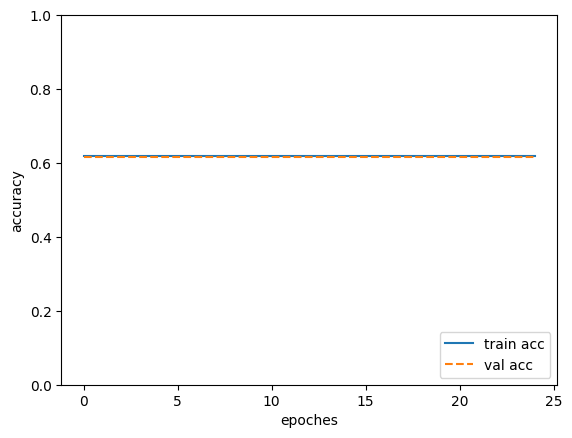

In [21]:
import matplotlib.pyplot as plt

markers = {'train': 'o', 'test': 's'}
x = np.arange(len(train_acc_list))
plt.plot(x, train_acc_list, label='train acc')
plt.plot(x, val_acc_list, label='val acc', linestyle='--')
plt.xlabel("epoches")
plt.ylabel('accuracy')
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

今回の精度は約62％になりました。このモデルの仕様では目標の精度には達していませんね。

２層のニューラルネットワークでは、思うように精度が出ないようです。

モデルをより複雑なものにすることのほかにも

エポック数を増やしてみたり、予測する要素を変更するなどの処理を行ってみると

精度が向上するかもしれません。

## （参考）提出用データの作成の仕方
参考として、今回学習した２層のニューラルネットワークモデルが

テスト用のデータを予測して、結果をcsvファイルとして出力するまでを

掲載してみました。

このcsvファイルを「修了課題提出用サイト」にアップロードすると結果を確認することができます。

In [22]:
# 提出用のデータをダウンロード
!wget 'https://drive.google.com/uc?export=download&id=1-1KX2NQmwUOXAstOE7c2INC1rRMNABVZ' -O titanic_test_x.csv

--2025-02-25 02:30:42--  https://drive.google.com/uc?export=download&id=1-1KX2NQmwUOXAstOE7c2INC1rRMNABVZ
Resolving drive.google.com (drive.google.com)... 108.177.12.100, 108.177.12.101, 108.177.12.102, ...
Connecting to drive.google.com (drive.google.com)|108.177.12.100|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1-1KX2NQmwUOXAstOE7c2INC1rRMNABVZ&export=download [following]
--2025-02-25 02:30:42--  https://drive.usercontent.google.com/download?id=1-1KX2NQmwUOXAstOE7c2INC1rRMNABVZ&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 172.217.204.132, 2607:f8b0:400c:c15::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|172.217.204.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 26481 (26K) [application/octet-stream]
Saving to: ‘titanic_test_x.csv’

titanic_test_x.csv  100%[===================>]  25.86K  --.-K

In [23]:
X_test = pd.read_csv('titanic_test_x.csv', index_col=0)
X_test

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,"Rosenbaum, Miss. Edith Louise",female,33,0,0,PC 17613,27.7208,A11,C,11,?,"Paris, France"
1,3,"Nysveen, Mr. Johan Hansen",male,61,0,0,345364,6.2375,?,S,?,?,?
2,3,"Eklund, Mr. Hans Linus",male,16,0,0,347074,7.7750,?,S,?,?,"Karberg, Sweden Jerome Junction, AZ"
3,3,"Khalil, Mr. Betros",male,?,1,0,2660,14.4542,?,C,?,?,?
4,1,"Bowen, Miss. Grace Scott",female,45,0,0,PC 17608,262.3750,?,C,4,?,"Cooperstown, NY"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
304,3,"Flynn, Mr. John",male,?,0,0,368323,6.9500,?,Q,?,?,?
305,1,"Carrau, Mr. Jose Pedro",male,17,0,0,113059,47.1000,?,S,?,?,"Montevideo, Uruguay"
306,2,"Brown, Miss. Edith Eileen",female,15,0,2,29750,39.0000,?,S,14,?,"Cape Town, South Africa / Seattle, WA"
307,1,"Cornell, Mrs. Robert Clifford (Malvina Helen L...",female,55,2,0,11770,25.7000,C101,S,2,?,"New York, NY"


In [24]:
# Demoで行った処理をテスト用のデータにも行う
X_test = X_test.replace('?', np.nan)
X_test['embarked'].fillna(freq_port, inplace=True)
X_test['embarked'] = X_test['embarked'].map( {'S': 0, 'C': 1, 'Q': 2} ).astype(int)
X_test['sex'] = X_test['sex'].map( {'female': 1, 'male': 0} ).astype(int)
X_test = X_test[['pclass','sex','embarked']]

<ipython-input-24-460c1d44fa6c>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_test['embarked'].fillna(freq_port, inplace=True)


In [25]:
# 学習させたモデルで予測する
y_pred = network.predict(X_test)
# このままだと確率値がでてしまうので、確率に基づいて最終的な判定値に変換する
y_pred = np.where(y_pred >= 0.5, 1, 0)
# pandasのDataFrame形式に変換し、CSV出力する
y_pred = pd.DataFrame(y_pred, columns=['survived'])
# csv形式で提出する
y_pred.to_csv('y_pred.csv')
y_pred

,survived
0,0
1,0
2,0
3,0
4,0
...,...
304,0
305,0
306,0
307,0


## （参考）sk-learnを利用した機械学習モデルを用いた予測

In [26]:
# ロジスティック回帰
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression()
logreg.fit(X_train, y_train)

acc_log = round(logreg.score(X_train, y_train) * 100, 2)
acc_log_val = round(logreg.score(X_val, y_val) * 100, 2)
print('学習精度:', acc_log)
print('検証精度:', acc_log_val)

# 予測する際
Y_pred = logreg.predict(X_test)

学習精度: 76.12
検証精度: 80.5
